<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-null  int64  
 2   product_id        10000 non-null  int64  
 3   category          10000 non-null  object 
 4   price             10000 non-null  float64
 5   quantity          10000 non-null  int64  
 6   order_date        10000 non-null  object 
 7   shipping_date     10000 non-null  object 
 8   delivery_status   10000 non-null  object 
 9   payment_method    10000 non-null  object 
 10  device_type       10000 non-null  object 
 11  channel           10000 non-null  object 
 12  shipping_address  10000 non-null  object 
 13  billing_address   10000 non-null  object 
 14  customer_segment  10000 non-null  object 
dtypes: float64(1), int64(3), object(11)
memory usage: 1.1+ MB


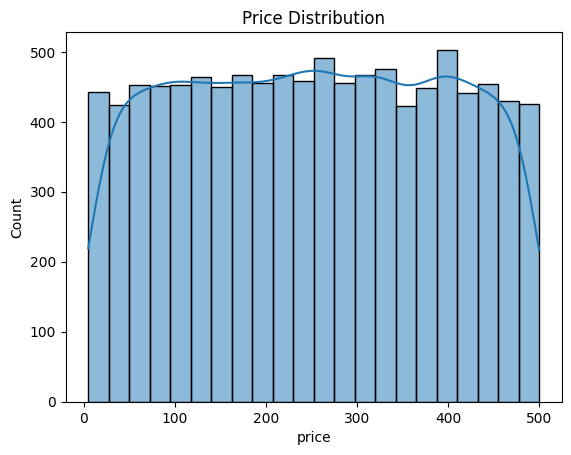

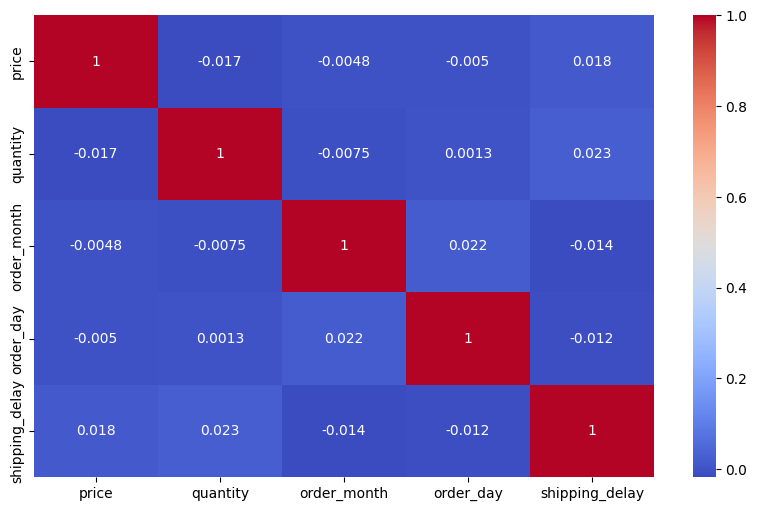

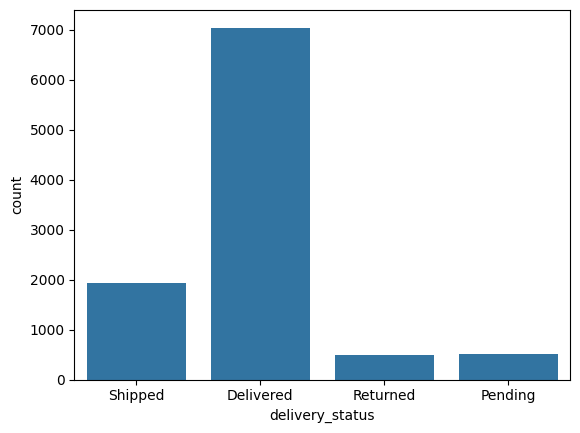

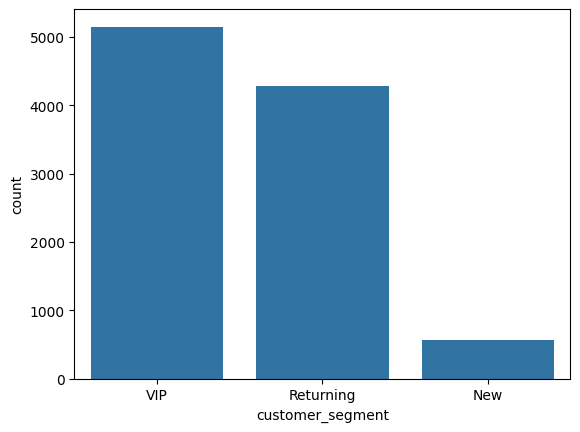

Transformed Shape: (10000, 29)


In [3]:
# Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../project/ecommerce_orders_raw_data.csv")

df.head()
df.info()

# Drop Unnecessary Columns
df = df.drop(columns=[
    "order_id",
    "customer_id",
    "product_id",
    "shipping_address",
    "billing_address"
])

# Feature Engineering (Dates)
df["order_date"] = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["shipping_delay"] = (df["shipping_date"] - df["order_date"]).dt.days

df = df.drop(columns=["order_date", "shipping_date"])

# EDA Numerical Distribution
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Categorical Distribution
sns.countplot(x="delivery_status", data=df)
plt.show()

sns.countplot(x="customer_segment", data=df)
plt.show()

# Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop(columns=["price"])

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Test Pipeline
X_transformed = preprocessor.fit_transform(X)
print("Transformed Shape:", X_transformed.shape)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix

# Regression Model (Task 3.2)
from sklearn.linear_model import SGDRegressor

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(max_iter=1000))
])

reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(reg_model, X, y, cv=5, scoring="neg_mean_squared_error")
print("Cross Validation MSE:", -scores.mean())

MSE: 20663.62771255064
MAE: 123.95722190044754
Cross Validation MSE: 20114.3279120488
